# AngioSim — Marker Tracking & Displacement Pipeline

Self-contained notebook that takes over the tracking and measurement work: undistorting the top-view footage, organizing both views into `data/final/`, tracking each marker bidirectionally from its per-video rest position, and producing per-marker displacement-from-rest graphs and CSVs.

**Pipeline:**
1. **Top-view undistortion** — undistort every `top_recording/*/footage.mp4` with the lens parameters tuned in the Analysis app (entered manually below) and write the result to `data/final/top_<no_acc|with_acc>_<pwm>.mp4`.
2. **Side-view copy** — copy every `side_recording/*.mp4` (no distortion correction needed) to `data/final/side_<no_acc|with_acc>_<pwm>.mp4`.
3. **Marker tracking** — for each video in `data/final/`, read its setup file (`{stem}_setup.json`, created by the Analysis app with rest-frame markers + index), then track each marker bidirectionally. Writes one CSV of raw `(x, y)` pixel positions and one spatial-trace PNG per video to `data/final/tracking/`.
4. **Displacement from rest** — from those tracked positions, compute each marker's pixel distance from its rest position over time; save one graph per video plus a combined CSV (and a "recap" overview graph) to `data/final/displacement/`.

Sync/trim/cross-condition comparison is intentionally **not** done here — that comes after eyeballing these per-video graphs, in a later pass over the exported CSVs.

> The Analysis app (`analysis/main.py`) is used to place markers at the rest frame for each video and save the setup file. The notebook reads those setup files to initialize tracking.

In [1]:
import re
import shutil
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "top_recording").exists():
            return p
    raise FileNotFoundError("Could not locate CardiacMotionTest root (expects data/top_recording)")


PROJECT_ROOT = find_project_root(Path.cwd())
ANALYSIS_ROOT = PROJECT_ROOT / "analysis"
DATA_DIR = PROJECT_ROOT / "data"
FINAL_DIR = DATA_DIR / "final"
TRACKING_DIR = FINAL_DIR / "tracking"
DISPLACEMENT_DIR = FINAL_DIR / "displacement"
for d in (FINAL_DIR, TRACKING_DIR, DISPLACEMENT_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ANALYSIS_ROOT))
from core.lens_calibration import LensCalibration
from core.marker_tracker import MarkerTracker

PROJECT_ROOT, FINAL_DIR

(WindowsPath('c:/Users/goldw/Documents/gswt/ITB/TA252602/Software/AngioSim/software/testing/CardiacMotionTest'),
 WindowsPath('c:/Users/goldw/Documents/gswt/ITB/TA252602/Software/AngioSim/software/testing/CardiacMotionTest/data/final'))

## Naming convention

Both `top_recording/` (folder names) and `side_recording/` (file names) encode the
condition as `with_accumulator_pwm_<duty>` / `no_accumulator_pwm_<duty>` — except a
handful of `side_recording` clips saved with a legacy `with_accumulator_<duty>` form
(no `pwm_` segment). `parse_condition` handles both; `final_stem` builds the new
`<view>_<with_acc|no_acc>_<duty>` name used everywhere from here on.

In [4]:
NAME_RE = re.compile(r"(with|no)_accumulator(?:_pwm)?_(\d+)")


def parse_condition(name: str) -> tuple[bool, int] | None:
    """Returns (accumulator_on, pwm_duty) parsed from a folder/file name, or None."""
    m = NAME_RE.search(name)
    if not m:
        return None
    return (m.group(1) == "with", int(m.group(2)))


def final_stem(view: str, accumulator: bool, pwm: int) -> str:
    return f"{view}_{'with_acc' if accumulator else 'no_acc'}_{pwm}"

## 1. Top-view — undistort and reorganize into `data/final/`

The top camera (Yahboom OV2710) has significant barrel distortion. Rather than
undistort on the fly every time the video is opened (as the Analysis app does), this
section bakes the correction in once: every `footage.mp4` is undistorted frame-by-frame
and written out under its new name — so everything downstream (tracking, eyeballing in
a player, etc.) works directly on a clean, already-corrected file.

**Lens parameters** below are copied by hand from the Analysis app's tuner
(`analysis/calibration/top_lens.json`, produced via "Lens Calibration..." → adjusting
k1/k2/focal scale until straight references look straight → Save). Re-paste them here
if the calibration is ever re-tuned.

In [ ]:
# Copied from analysis/calibration/top_lens.json — the shared, once-per-camera
# radial-distortion correction tuned in the Analysis app.
TOP_LENS = LensCalibration(
    label="top",
    frame_width=1920,
    frame_height=1080,
    k1=-1.02,
    k2=0.357,
    p1=0.0,
    p2=0.0,
    focal_scale=1.024,
)


def undistort_video(src: Path, dst: Path, lens: LensCalibration) -> None:
    cap = cv2.VideoCapture(str(src))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = cv2.VideoWriter(str(dst), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            writer.write(lens.undistort_frame(frame))
    finally:
        cap.release()
        writer.release()


for folder in sorted((DATA_DIR / "top_recording").iterdir()):
    if not folder.is_dir():
        continue
    video = folder / "footage.mp4"
    cond = parse_condition(folder.name)
    if cond is None or not video.exists():
        print(f"  skip {folder.name} (no condition parsed / no footage.mp4)")
        continue
    accumulator, pwm = cond
    dst = FINAL_DIR / f"{final_stem('top', accumulator, pwm)}.mp4"
    if dst.exists():
        print(f"  already done: {dst.name}")
        continue
    print(f"  undistorting {folder.name} -> {dst.name} ...")
    undistort_video(video, dst, TOP_LENS)

print("Top-view done.")

  undistorting 20260605_212201_with_accumulator_pwm_60 -> top_with_acc_60.mp4 ...
  undistorting 20260605_212222_with_accumulator_pwm_80 -> top_with_acc_80.mp4 ...
  undistorting 20260605_212253_with_accumulator_pwm_100 -> top_with_acc_100.mp4 ...
  undistorting 20260605_212330_with_accumulator_pwm_130 -> top_with_acc_130.mp4 ...
  undistorting 20260605_212424_with_accumulator_pwm_170 -> top_with_acc_170.mp4 ...
  undistorting 20260605_212536_with_accumulator_pwm_200 -> top_with_acc_200.mp4 ...
  undistorting 20260605_212607_with_accumulator_pwm_250 -> top_with_acc_250.mp4 ...
  undistorting 20260605_213034_no_accumulator_pwm_100 -> top_no_acc_100.mp4 ...
  undistorting 20260605_213135_no_accumulator_pwm_150 -> top_no_acc_150.mp4 ...


## 2. Side-view — copy and rename into `data/final/`

The side/phone camera has negligible distortion, so no correction is applied — files
are simply copied across under the unified naming scheme.

In [4]:
for video in sorted((DATA_DIR / "side_recording").glob("*.mp4")):
    cond = parse_condition(video.stem)
    if cond is None:
        print(f"  skip {video.name} (no condition parsed)")
        continue
    accumulator, pwm = cond
    dst = FINAL_DIR / f"{final_stem('side', accumulator, pwm)}.mp4"
    if dst.exists():
        print(f"  already done: {dst.name}")
        continue
    shutil.copy2(video, dst)
    print(f"  copied {video.name} -> {dst.name}")

print("Side-view done.")

  copied 20260605_212155_with_accumulator_pwm_60.mp4 -> side_with_acc_60.mp4
  copied 20260605_212222_with_accumulator_pwm_80.mp4 -> side_with_acc_80.mp4
  copied 20260605_212253_with_accumulator_pwm_100.mp4 -> side_with_acc_100.mp4
  copied 20260605_212329_with_accumulator_pwm_130.mp4 -> side_with_acc_130.mp4
  copied 20260605_212424_with_accumulator_170.mp4 -> side_with_acc_170.mp4
  copied 20260605_212537_with_accumulator_200.mp4 -> side_with_acc_200.mp4
  copied 20260605_212609_with_accumulator_250.mp4 -> side_with_acc_250.mp4
  copied 20260605_213042_no_accumulator_100.mp4 -> side_no_acc_100.mp4
  copied 20260605_213140_no_accumulator_150.mp4 -> side_no_acc_150.mp4
  copied 20260605_213317_no_accumulator_200.mp4 -> side_no_acc_200.mp4
  copied 20260605_213356_no_accumulator_250.mp4 -> side_no_acc_250.mp4
  copied 20260605_213516_with_accumulator_pwm_150.mp4 -> side_with_acc_150.mp4
Side-view done.


## 3. Marker tracking — from per-video setup files

Each video's rest frame position and marker pixel locations are stored in a setup file next to the video: `data/final/{video_stem}_setup.json`. This file is created by the Analysis app when you place markers and click **Save Setup**.

**Workflow:**

1. Open a video from `data/final/` in the Analysis app (`analysis/main.py`)
2. Scrub to the frame you consider the "rest" (baseline) position for that specific video
3. Click **+ Add Marker** and place each marker on the heart surface at that rest frame
4. Click **Save Setup** — writes `data/final/{video_stem}_setup.json` with the marker positions and rest frame index
5. Repeat for every video

Once all videos have setup files, run this section. The notebook will:
- Read each `_setup.json` to get that video's markers and rest frame index
- Run bidirectional Lucas-Kanade tracking (forward from rest frame to end, backward from rest frame to start)
- Cache raw `(x, y)` pixel positions to `<stem>_positions.csv` (won't re-track if CSV exists)
- Generate a spatial-trace PNG per video (marker path as X-Y scatter)

Output: `data/final/tracking/{stem}_positions.csv` and `{stem}_trace.png`

In [ ]:
def view_of(video: Path) -> str:
    return "top" if video.stem.startswith("top_") else "side"


def load_setup(video_path: Path) -> tuple[list[tuple[int, int]], int] | None:
    """Load markers and rest_frame_index from <video_stem>_setup.json. Returns (markers, rest_frame_index) or None."""
    setup_path = video_path.parent / (video_path.stem + "_setup.json")
    if not setup_path.exists():
        return None
    import json
    with open(setup_path) as f:
        data = json.load(f)
    markers = [tuple(m) for m in data["markers"]]
    rest_frame_index = data["rest_frame_index"]
    return (markers, rest_frame_index)


def track_video(video_path: Path, markers: list[tuple[int, int]], rest_frame_index: int) -> pd.DataFrame:
    """Bidirectional Lucas-Kanade tracking from the rest frame -- mirrors the app's AnalysisRunner."""
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    rows: dict[int, tuple[float, list[tuple[float, float]]]] = {}

    cap.set(cv2.CAP_PROP_POS_FRAMES, rest_frame_index)
    ok, rest_frame = cap.read()
    if not ok:
        raise RuntimeError(f"Cannot read rest frame {rest_frame_index} of {video_path.name}")

    forward = MarkerTracker()
    forward.initialize(rest_frame, markers)
    rows[rest_frame_index] = (rest_frame_index / fps, list(markers))

    idx = rest_frame_index + 1
    while idx < total:
        ok, frame = cap.read()
        if not ok:
            break
        pos = forward.track(frame)
        if pos is None:
            print(f"    [forward] marker lost at frame {idx}")
            break
        rows[idx] = (idx / fps, pos)
        idx += 1

    if rest_frame_index > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        buffer = []
        for i in range(rest_frame_index):
            ok, frame = cap.read()
            if not ok:
                break
            buffer.append((i, frame))

        backward = MarkerTracker()
        backward.initialize(rest_frame, markers)
        for i, frame in reversed(buffer):
            pos = backward.track(frame)
            if pos is None:
                print(f"    [backward] marker lost at frame {i}")
                break
            rows[i] = (i / fps, pos)

    cap.release()

    out = []
    for frame in sorted(rows):
        time_s, pos = rows[frame]
        row = {"frame": frame, "time_s": time_s}
        for i, (x, y) in enumerate(pos):
            row[f"m{i}_x_px"], row[f"m{i}_y_px"] = x, y
        out.append(row)
    return pd.DataFrame(out)


def plot_spatial_traces(df, markers, title, out_path):
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, ax = plt.subplots(figsize=(6, 6))
    for i, (rx, ry) in enumerate(markers):
        xcol, ycol = f"m{i}_x_px", f"m{i}_y_px"
        if xcol not in df.columns:
            continue
        color = colors[i % len(colors)]
        ax.plot(df[xcol], df[ycol], linewidth=1.0, color=color, label=f"Marker {i}")
        ax.plot(rx, ry, "x", color=color, markersize=9)
    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X (px)")
    ax.set_ylabel("Y (px)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)


videos = sorted(FINAL_DIR.glob("*.mp4"))
tracked = {}
missing_setup = []

for video in videos:
    view = view_of(video)
    setup = load_setup(video)
    
    if setup is None:
        missing_setup.append(video.stem)
        continue
    
    markers, rest_idx = setup
    csv_path = TRACKING_DIR / f"{video.stem}_positions.csv"

    if csv_path.exists():
        print(f"  already tracked: {video.stem}")
        df = pd.read_csv(csv_path)
    else:
        print(f"  tracking {video.name} ...")
        df = track_video(video, markers, rest_idx)
        df.to_csv(csv_path, index=False)

    plot_spatial_traces(df, markers, f"Marker spatial traces -- {video.stem}",
                        TRACKING_DIR / f"{video.stem}_trace.png")
    tracked[video.stem] = (view, df, markers)

if missing_setup:
    print(f"\n⚠️  Missing setup files for {len(missing_setup)} video(s):")
    for stem in missing_setup:
        print(f"    - {stem} → open in Analysis app, place markers, Save Setup")
    print()

print(f"Tracking done -- {len(tracked)} video(s) with setup, CSVs + traces in {TRACKING_DIR}")

## 4. Displacement from rest

For each video, each marker's distance from its rest position
(`hypot(x - rest_x, y - rest_y)`, in pixels) over time — a per-video graph plus one
combined CSV across every recording, and a "recap" overlay so all of them can be
scanned for anomalies/sync issues before any cutting or syncing happens.

In [19]:
# Pixel-to-mm conversion factors (from measurement tool)
TOP_MM_PER_PX = 0.1664
SIDE_MM_PER_PX = 0.1197


def with_displacement(df: pd.DataFrame, markers: list[tuple[int, int]], mm_per_px: float = 1.0) -> pd.DataFrame:
    df = df.copy()
    for i, (rx, ry) in enumerate(markers):
        xcol, ycol = f"m{i}_x_px", f"m{i}_y_px"
        if xcol in df.columns:
            disp_px = np.hypot(df[xcol] - rx, df[ycol] - ry)
            df[f"m{i}_disp_px"] = disp_px
            df[f"m{i}_disp_mm"] = disp_px * mm_per_px
    return df


colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
combined_rows = []

for stem, (view, pos_df, markers) in tracked.items():
    mm_per_px = TOP_MM_PER_PX if view == "top" else SIDE_MM_PER_PX
    df = with_displacement(pos_df, markers, mm_per_px)
    disp_px_cols = [c for c in df.columns if c.endswith("_disp_px")]
    disp_mm_cols = [c for c in df.columns if c.endswith("_disp_mm")]

    # --- Graph 1: px only ---
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, col in enumerate(disp_px_cols):
        ax.plot(df["time_s"], df[col], linewidth=1.0, color=colors[i % len(colors)],
                label=col.removesuffix("_disp_px"))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Displacement from rest (px)")
    ax.set_title(f"Displacement from rest -- {stem}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(DISPLACEMENT_DIR / f"{stem}_displacement_px.png", dpi=150)
    plt.close(fig)

    # --- Graph 2: mm only ---
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, col in enumerate(disp_mm_cols):
        ax.plot(df["time_s"], df[col], linewidth=1.0, color=colors[i % len(colors)],
                label=col.removesuffix("_disp_mm"))
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Displacement from rest (mm)")
    ax.set_title(f"Displacement from rest -- {stem}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(DISPLACEMENT_DIR / f"{stem}_displacement_mm.png", dpi=150)
    plt.close(fig)

    # --- Graph 3: combined (dual y-axis: px left, mm right) ---
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()  # Create second y-axis sharing the same x-axis
    
    # Plot px data on left axis
    for i, col in enumerate(disp_px_cols):
        ax1.plot(df["time_s"], df[col], linewidth=1.0, color=colors[i % len(colors)],
                 label=col.removesuffix("_disp_px"))
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Displacement from rest (px)", color=colors[0])
    ax1.tick_params(axis='y', labelcolor=colors[0])
    
    # Plot mm data on right axis (same curves, just scaled differently)
    for i, col in enumerate(disp_mm_cols):
        ax2.plot(df["time_s"], df[col], linewidth=1.0, color=colors[i % len(colors)],
                 linestyle='--', alpha=0.5)
    ax2.set_ylabel("Displacement from rest (mm)", color=colors[1] if len(colors) > 1 else colors[0])
    ax2.tick_params(axis='y', labelcolor=colors[1] if len(colors) > 1 else colors[0])
    
    ax1.set_title(f"Displacement from rest -- {stem}")
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(alpha=0.3)
    
    fig.tight_layout()
    fig.savefig(DISPLACEMENT_DIR / f"{stem}_displacement_combined.png", dpi=150)
    plt.close(fig)

    # CSV includes BOTH px and mm
    row_block = df[["frame", "time_s"] + disp_px_cols + disp_mm_cols].copy()
    row_block.insert(0, "video", stem)
    row_block.insert(1, "view", view)
    combined_rows.append(row_block)

displacement = pd.concat(combined_rows, ignore_index=True) if combined_rows else pd.DataFrame()
displacement_csv = DISPLACEMENT_DIR / "all_displacement.csv"
displacement.to_csv(displacement_csv, index=False)
print(f"Saved {len(displacement)} rows across {len(combined_rows)} video(s) to {displacement_csv}")
print(f"Generated graphs: *_displacement_px.png, *_displacement_mm.png, *_displacement_combined.png (dual y-axis)")
displacement.head()

Saved 11380 rows across 24 video(s) to c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest\data\final\displacement\all_displacement.csv
Generated graphs: *_displacement_px.png, *_displacement_mm.png, *_displacement_combined.png (dual y-axis)


,video,view,frame,time_s,m0_disp_px,m1_disp_px,m0_disp_mm,m1_disp_mm,m2_disp_px,m3_disp_px,m2_disp_mm,m3_disp_mm
0,side_no_acc_100,side,0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,side_no_acc_100,side,1,0.033335,0.446344,0.525597,0.053427,0.062914,NaN,NaN,NaN,NaN
2,side_no_acc_100,side,2,0.066671,0.270672,1.029705,0.032399,0.123256,NaN,NaN,NaN,NaN
3,side_no_acc_100,side,3,0.100006,2.849035,1.585935,0.341030,0.189836,NaN,NaN,NaN,NaN
4,side_no_acc_100,side,4,0.133341,2.497191,1.850106,0.298914,0.221458,NaN,NaN,NaN,NaN


## 5. Recap — Grid view of all dual-axis displacement graphs

View all combined graphs in a configurable grid. Adjust `rows`, `cols`, and `filter_pattern` to customize.

Found 24 graph(s) matching filter: ''
Displaying in 6x4 grid



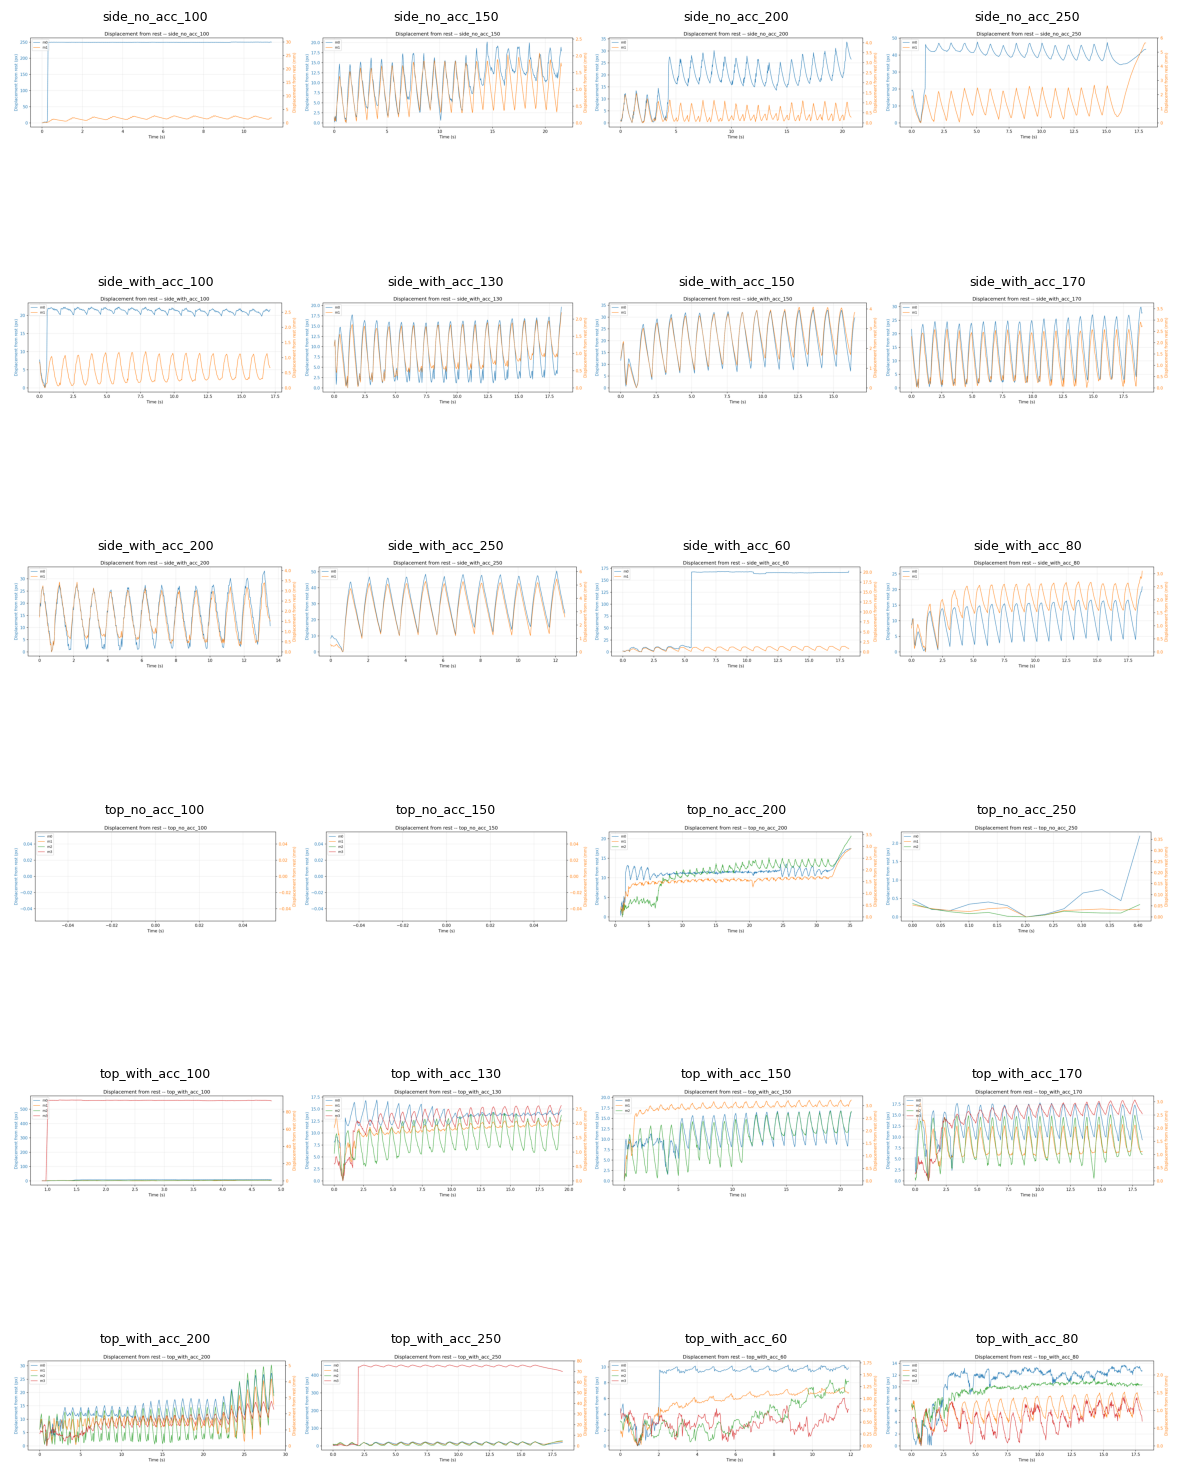


Recap grid saved to: c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest\data\final\displacement\recap_grid.png


In [ ]:
from PIL import Image

# === CONFIGURATION ===
rows = 12  # Number of rows in grid
cols = 2  # Number of columns in grid
filter_pattern = ""  # Filter by filename pattern (e.g., "top_with_acc" or "side_no_acc"), "" for all

# Load all combined displacement graphs
graph_files = sorted(DISPLACEMENT_DIR.glob("*_displacement_combined.png"))

# Filter by pattern if specified
if filter_pattern:
    graph_files = [f for f in graph_files if filter_pattern in f.stem]

print(f"Found {len(graph_files)} graph(s) matching filter: '{filter_pattern}'")
print(f"Displaying in {rows}x{cols} grid\n")

# Create grid
fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
axes = axes.flatten()  # Flatten for easy indexing

# Load and display images
for idx, img_path in enumerate(graph_files):
    if idx >= len(axes):
        break
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(img_path.stem.replace("_displacement_combined", ""), fontsize=9)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(len(graph_files), len(axes)):
    axes[idx].axis('off')

# Very tight spacing between rows and columns
fig.subplots_adjust(hspace=-0.1, wspace=-0.0)

fig.savefig(DISPLACEMENT_DIR / "recap_grid.png", dpi=100, bbox_inches='tight')
plt.show()

print(f"\nRecap grid saved to: {DISPLACEMENT_DIR / 'recap_grid.png'}")

## 6. Export with_acc_150 (5–10s window) to Excel

Export top and side views at PWM 150 with accumulator, filtered to the 5–10s time window for frequency analysis.

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

# Load the displacement data
displacement = pd.read_csv(DISPLACEMENT_DIR / "all_displacement.csv")

# Filter for with_acc_150 (both top and side) in the 5-10s window
time_window = (displacement['time_s'] >= 5) & (displacement['time_s'] <= 10)
with_acc_150 = displacement[time_window & displacement['video'].str.contains('with_acc_150')]

# Create Excel file with separate sheets for top and side
excel_path = DISPLACEMENT_DIR / "with_acc_150_5-10s.xlsx"
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    for view in ['top', 'side']:
        view_data = with_acc_150[with_acc_150['view'] == view]
        if len(view_data) > 0:
            # Select relevant displacement columns (drop pixel coordinates, keep displacement)
            cols_to_export = ['frame', 'time_s'] + [c for c in view_data.columns if '_disp_' in c]
            view_data[cols_to_export].to_excel(writer, sheet_name=view, index=False)
            
            # Format the worksheet
            ws = writer.sheets[view]
            header_fill = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
            header_font = Font(bold=True, color="FFFFFF")
            for cell in ws[1]:
                cell.fill = header_fill
                cell.font = header_font
            
            # Auto-adjust column widths
            for i, col in enumerate(cols_to_export, start=1):
                ws.column_dimensions[get_column_letter(i)].width = 12

print(f"Exported to: {excel_path}")
print(f"Top view: {len(with_acc_150[with_acc_150['view']=='top'])} rows")
print(f"Side view: {len(with_acc_150[with_acc_150['view']=='side'])} rows")

## 7. Cardiac phase segmentation (systole/diastole)

Extract displacement data for with_acc_150 segmented by cardiac phase boundaries. Provide a list of time points representing phase transitions (systole start → systole end → diastole start → diastole end → systole start, etc.).

In [ ]:
# INPUT: List of time points marking cardiac phase boundaries
# Format: [systole_start, systole_end, diastole_start, diastole_end, systole_start, ...]
# Edit this list with your measured time values from the graphs
phase_times = [5.85, 6.28, 6.28, 6.92]  # Example: syst[5.85-6.28], dias[6.90-7.33]

# Load displacement data
displacement = pd.read_csv(DISPLACEMENT_DIR / "all_displacement.csv")

# Process top and side separately
for view in ['top', 'side']:
    print(f"\n{'='*60}")
    print(f"  {view.upper()} VIEW - with_acc_150")
    print(f"{'='*60}")
    
    view_data = displacement[
        (displacement['view'] == view) & 
        (displacement['video'] == f'{view}_with_acc_150')
    ].copy()
    
    if len(view_data) == 0:
        print(f"No data found for {view}_with_acc_150")
        continue
    
    print(f"\nTotal frames: {len(view_data)}, Duration: {view_data['time_s'].min():.2f}s - {view_data['time_s'].max():.2f}s")
    print(f"Phase boundaries: {phase_times}\n")
    
    # Extract displacement columns
    disp_cols = [c for c in view_data.columns if '_disp_mm' in c]
    
    # Segment by phases
    for i in range(0, len(phase_times)-1, 2):
        phase_start = phase_times[i]
        phase_end = phase_times[i+1]
        phase_type = "SYSTOLE" if i % 4 == 0 else "DIASTOLE"
        
        phase_data = view_data[
            (view_data['time_s'] >= phase_start) & 
            (view_data['time_s'] <= phase_end)
        ]
        
        if len(phase_data) == 0:
            print(f"  {phase_type} [{phase_start:.2f}-{phase_end:.2f}s]: No data")
            continue
        
        print(f"  {phase_type} [{phase_start:.2f}-{phase_end:.2f}s] ({len(phase_data)} frames):")
        
        # Print marker stats for this phase
        for col in disp_cols:
            marker = col.split('_')[0]
            mean_val = phase_data[col].mean()
            max_val = phase_data[col].max()
            min_val = phase_data[col].min()
            print(f"    {marker}: mean={mean_val:.3f}mm, min={min_val:.3f}mm, max={max_val:.3f}mm, range={max_val-min_val:.3f}mm")
        
        # Print first 5 rows of this phase
        print(f"    Data sample:")
        cols_to_show = ['frame', 'time_s'] + disp_cols
        for idx, row in phase_data[cols_to_show].head(5).iterrows():
            print(f"      {row.to_dict()}")

## 8. Plot dual-axis graph with time range

Create dual-axis displacement graphs (px and mm) for any video, restricted to a specific time window.

In [2]:
def plot_displacement_range(video_name: str, time_start: float, time_end: float, save: bool = True) -> None:
    """
    Create a dual-axis displacement graph (px left, mm right) for a video within a time range.
    
    Args:
        video_name: Video identifier (e.g., 'top_with_acc_150', 'side_with_acc_130')
        time_start: Start time in seconds
        time_end: End time in seconds
        save: Whether to save the figure (default: True)
    """
    # Load displacement data
    displacement = pd.read_csv(DISPLACEMENT_DIR / "all_displacement.csv")
    
    # Filter for the video and time range
    video_data = displacement[
        (displacement['video'] == video_name) &
        (displacement['time_s'] >= time_start) &
        (displacement['time_s'] <= time_end)
    ].copy()
    
    if len(video_data) == 0:
        print(f"Error: No data found for {video_name} in time range [{time_start:.2f}s - {time_end:.2f}s]")
        return
    
    # Extract displacement columns
    disp_px_cols = [c for c in video_data.columns if c.endswith('_disp_px')]
    disp_mm_cols = [c for c in video_data.columns if c.endswith('_disp_mm')]
    
    if not disp_px_cols:
        print(f"Error: No displacement data found for {video_name}")
        return
    
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    
    # Create dual-axis plot
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    
    # Plot px data on left axis (solid lines)
    for i, col in enumerate(disp_px_cols):
        ax1.plot(video_data['time_s'], video_data[col], linewidth=1.5, 
                color=colors[i % len(colors)], label=col.replace('_disp_px', ''), marker='o', markersize=3)
    
    ax1.set_xlabel('Time (s)', fontsize=11)
    ax1.set_ylabel('Displacement from rest (px)', fontsize=11, color=colors[0])
    ax1.tick_params(axis='y', labelcolor=colors[0])
    ax1.grid(True, alpha=0.3)
    
    # Plot mm data on right axis (dashed lines)
    for i, col in enumerate(disp_mm_cols):
        ax2.plot(video_data['time_s'], video_data[col], linewidth=1.5, 
                color=colors[i % len(colors)], linestyle='--', alpha=0.7, marker='s', markersize=2)
    
    ax2.set_ylabel('Displacement from rest (mm)', fontsize=11, color=colors[1] if len(colors) > 1 else colors[0])
    ax2.tick_params(axis='y', labelcolor=colors[1] if len(colors) > 1 else colors[0])
    
    ax1.set_title(f'{video_name} [{time_start:.2f}s - {time_end:.2f}s]', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    
    fig.tight_layout()
    
    if save:
        filename = DISPLACEMENT_DIR / f"{video_name}_{time_start:.2f}-{time_end:.2f}s_dual_axis.png"
        fig.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved: {filename}")
    
    plt.show()

# === EXAMPLE USAGE ===
# Uncomment and modify to create graphs for any video/time range:
# plot_displacement_range('top_with_acc_150', 5.0, 10.0)
# plot_displacement_range('side_with_acc_150', 5.0, 10.0)
print("Function 'plot_displacement_range' is ready to use.")

Function 'plot_displacement_range' is ready to use.


Saved: c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest\data\final\displacement\top_with_acc_150_5.00-10.00s_dual_axis.png


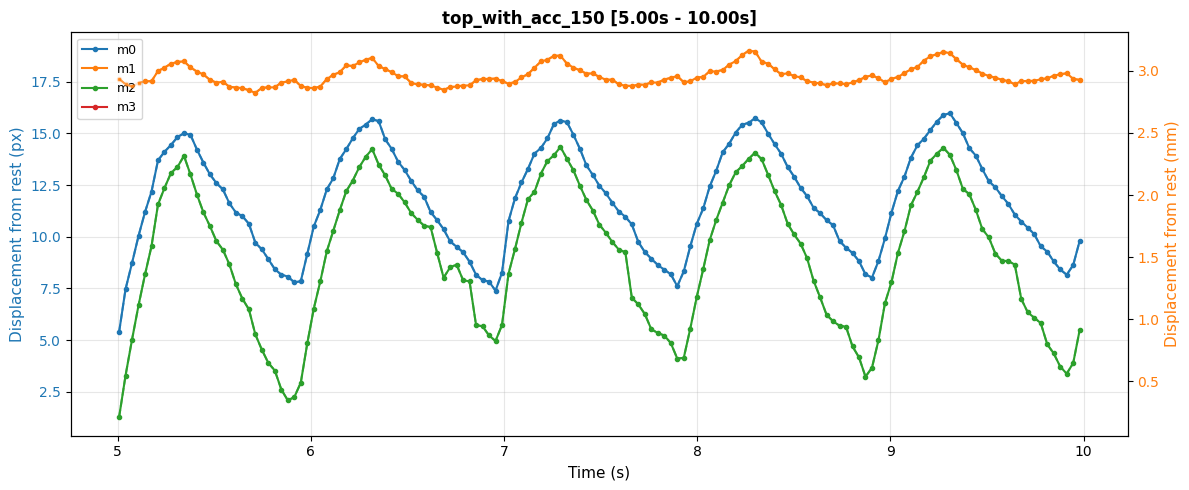

Saved: c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest\data\final\displacement\side_with_acc_150_5.00-10.00s_dual_axis.png


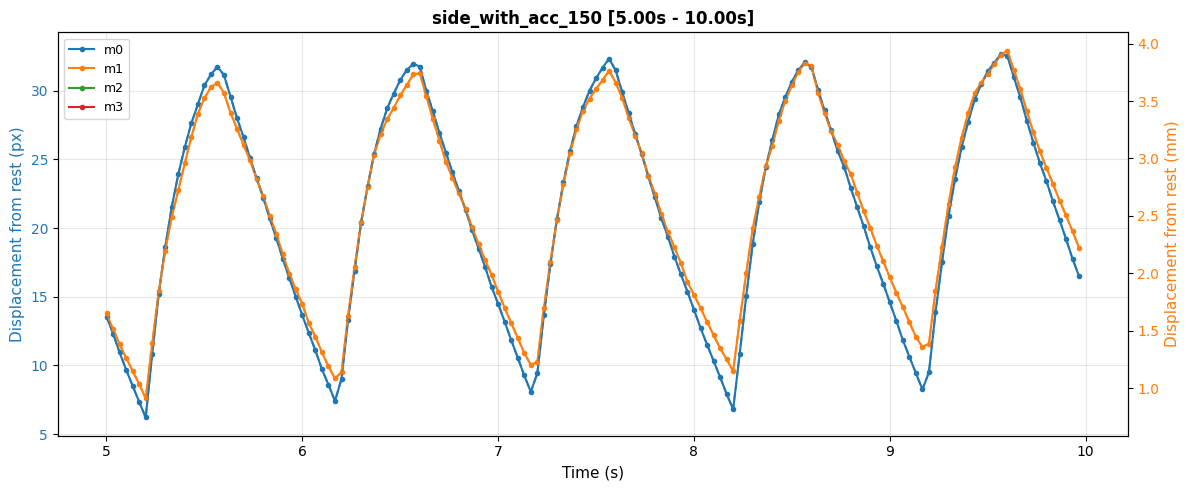

Error: No data found for top_no_acc_150 in time range [5.00s - 10.00s]
Saved: c:\Users\goldw\Documents\gswt\ITB\TA252602\Software\AngioSim\software\testing\CardiacMotionTest\data\final\displacement\side_no_acc_150_5.00-10.00s_dual_axis.png


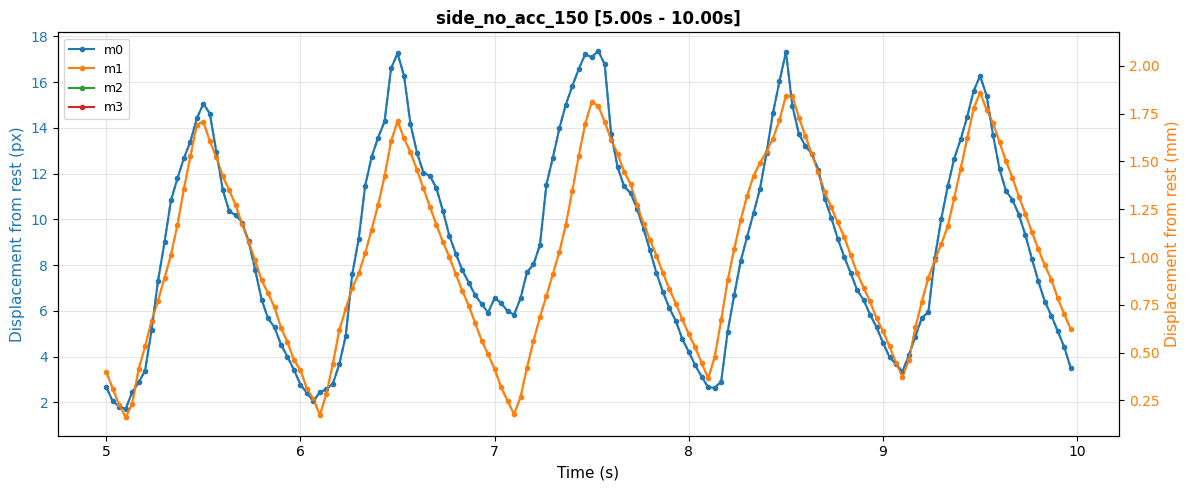

In [10]:
plot_displacement_range('top_with_acc_150', 5.0, 10.0)
plot_displacement_range('side_with_acc_150', 5.0, 10.0)
plot_displacement_range('top_no_acc_150', 5.0, 10.0)
plot_displacement_range('side_no_acc_150', 5.0, 10.0)
# plot_displacement_range('top_with_acc_130', 3.0, 7.0)
# plot_displacement_range('side_with_acc_130', 3.0, 7.0)

## 9. Fix: re-track `top_no_acc_150` with per-marker robust tracking

Diagnosis: `track_video` (Section 3) uses `MarkerTracker`, which runs all 4 markers through a single `calcOpticalFlowPyrLK` call and aborts the **whole video** the instant **any one** marker is lost. For `top_no_acc_150`, marker **0** (placed at `(755, 307)`, apparently on a low-texture patch — `calcOpticalFlowPyrLK` returns `status=0, err=0` for it immediately at frame 0→1) is untrackable, while markers 1–3 track cleanly through the entire clip. That single bad marker killed tracking for everything, leaving only a 1-row stub.

`track_video_robust` below tracks each marker **independently**: a lost marker just becomes `NaN` from that frame onward while the others keep going. This cell re-tracks **only** `top_no_acc_150`, regenerates its displacement graph, and patches its rows into `all_displacement.csv` (replacing the old 1-row stub).

In [ ]:
def track_video_robust(video_path: Path, markers: list[tuple[int, int]], rest_frame_index: int) -> pd.DataFrame:
    """Per-marker bidirectional LK tracking -- a lost marker goes NaN but doesn't abort the others."""
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    n = len(markers)
    rows: dict[int, tuple[float, list[tuple[float, float]]]] = {}

    cap.set(cv2.CAP_PROP_POS_FRAMES, rest_frame_index)
    ok, rest_frame = cap.read()
    if not ok:
        raise RuntimeError(f"Cannot read rest frame {rest_frame_index} of {video_path.name}")
    rest_gray = cv2.cvtColor(rest_frame, cv2.COLOR_BGR2GRAY)
    rows[rest_frame_index] = (rest_frame_index / fps, list(markers))

    def track_pass(frames_with_indices):
        points = np.array(markers, dtype=np.float32).reshape(-1, 1, 2)
        alive = [True] * n
        prev_gray = rest_gray
        for idx, frame in frames_with_indices:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            new_pts, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, points, None, **MarkerTracker.LK_PARAMS)
            prev_gray = gray
            pos = []
            for i in range(n):
                lost_now = (not alive[i]) or new_pts is None or status is None or status[i][0] != 1
                if lost_now:
                    if alive[i]:
                        print(f"    marker {i} lost at frame {idx}")
                    alive[i] = False
                    pos.append((np.nan, np.nan))
                else:
                    x, y = float(new_pts[i][0][0]), float(new_pts[i][0][1])
                    points[i][0] = [x, y]
                    pos.append((x, y))
            rows[idx] = (idx / fps, pos)
            if not any(alive):
                break

    def forward_frames():
        idx = rest_frame_index + 1
        while idx < total:
            ok, frame = cap.read()
            if not ok:
                return
            yield idx, frame
            idx += 1
    track_pass(forward_frames())

    if rest_frame_index > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        buffer = []
        for i in range(rest_frame_index):
            ok, frame = cap.read()
            if not ok:
                break
            buffer.append((i, frame))
        track_pass(reversed(buffer))

    cap.release()

    out = []
    for frame in sorted(rows):
        time_s, pos = rows[frame]
        row = {"frame": frame, "time_s": time_s}
        for i, (x, y) in enumerate(pos):
            row[f"m{i}_x_px"], row[f"m{i}_y_px"] = x, y
        out.append(row)
    return pd.DataFrame(out)


# --- Re-track only top_no_acc_150 ---
fix_name = "top_no_acc_150"
fix_video_path = FINAL_DIR / f"{fix_name}.mp4"
fix_markers, fix_rest_idx = load_setup(fix_video_path)

print(f"Re-tracking {fix_name} (robust, per-marker)...")
fix_df = track_video_robust(fix_video_path, fix_markers, fix_rest_idx)
fix_csv_path = TRACKING_DIR / f"{fix_name}_positions.csv"
fix_df.to_csv(fix_csv_path, index=False)
print(f"  saved {len(fix_df)} rows -> {fix_csv_path}")

plot_spatial_traces(fix_df, fix_markers, f"Marker spatial traces -- {fix_name} (robust re-track)",
                    TRACKING_DIR / f"{fix_name}_trace.png")

# --- Recompute displacement & combined dual-axis graph ---
fix_disp = with_displacement(fix_df, fix_markers, TOP_MM_PER_PX)
disp_px_cols = [c for c in fix_disp.columns if c.endswith("_disp_px")]
disp_mm_cols = [c for c in fix_disp.columns if c.endswith("_disp_mm")]

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
for i, col in enumerate(disp_px_cols):
    ax1.plot(fix_disp["time_s"], fix_disp[col], linewidth=1.0, color=colors[i % len(colors)],
             label=col.removesuffix("_disp_px"))
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Displacement from rest (px)", color=colors[0])
ax1.tick_params(axis='y', labelcolor=colors[0])
for i, col in enumerate(disp_mm_cols):
    ax2.plot(fix_disp["time_s"], fix_disp[col], linewidth=1.0, color=colors[i % len(colors)],
             linestyle='--', alpha=0.5)
ax2.set_ylabel("Displacement from rest (mm)", color=colors[1] if len(colors) > 1 else colors[0])
ax2.tick_params(axis='y', labelcolor=colors[1] if len(colors) > 1 else colors[0])
ax1.set_title(f"Displacement from rest -- {fix_name} (robust re-track; marker 0 NaN after frame {fix_rest_idx + 1})")
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DISPLACEMENT_DIR / f"{fix_name}_displacement_combined.png", dpi=150)
plt.show()
plt.close(fig)

# --- Patch all_displacement.csv: drop old stub rows for this video, append new ---
all_disp_path = DISPLACEMENT_DIR / "all_displacement.csv"
all_displacement = pd.read_csv(all_disp_path)
all_displacement = all_displacement[all_displacement["video"] != fix_name]
fix_row_block = fix_disp[["frame", "time_s"] + disp_px_cols + disp_mm_cols].copy()
fix_row_block.insert(0, "video", fix_name)
fix_row_block.insert(1, "view", "top")
all_displacement = pd.concat([all_displacement, fix_row_block], ignore_index=True)
all_displacement.to_csv(all_disp_path, index=False)
print(f"  patched all_displacement.csv: {fix_name} now has {len(fix_row_block)} rows")
